In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
data = pd.read_excel("canada_per_capita_income.xlsx")

In [5]:
data.head()

,year,income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [6]:
data.shape

(47, 2)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    47 non-null     int64  
 1   income  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 880.0 bytes


In [8]:
x = data.iloc[ : , 0 : 1].values
y = data.iloc[: , -1].values

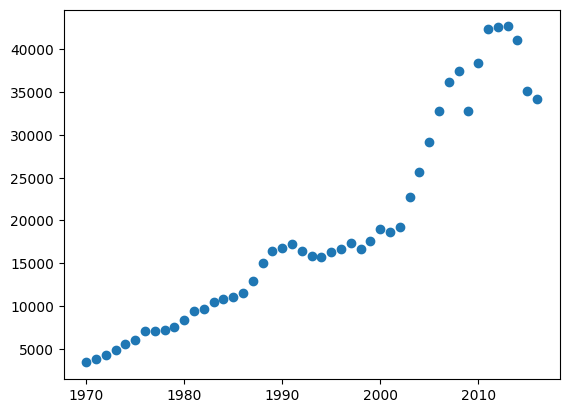

In [13]:
plt.scatter(x, y)
plt.show()

In [15]:
x_train, x_test , y_train , y_test = train_test_split(x , y , test_size = 0.3 , random_state = 0)
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(x_test)

In [17]:
y_pred

array([23866.56302985, 28104.14918647, 25561.5974925 ,  3526.14947809,
       15391.39071662,  9458.77009735, 35731.80426838, 26409.11472382,
       18781.45964191,  8611.25286603, 23019.04579853, 27256.63195514,
       24714.08026117, 36579.3214997 ,  1831.11501545])

In [18]:
r2_score(y_pred, y_test)

0.7316712117654629

In [19]:
model.score(x_test, y_test)

0.7537443860326112

In [20]:
model.predict([[2020] , [2021]])

array([42511.94211896, 43359.45935029])

In [21]:
import joblib
joblib.dump(model , "Canada_caption_income_predication_model.pkl")

['Canada_caption_income_predication_model.pkl']

In [22]:
load_model = joblib.load("Canada_caption_income_predication_model.pkl")

In [23]:
load_model.predict([[2021]])

array([43359.45935029])

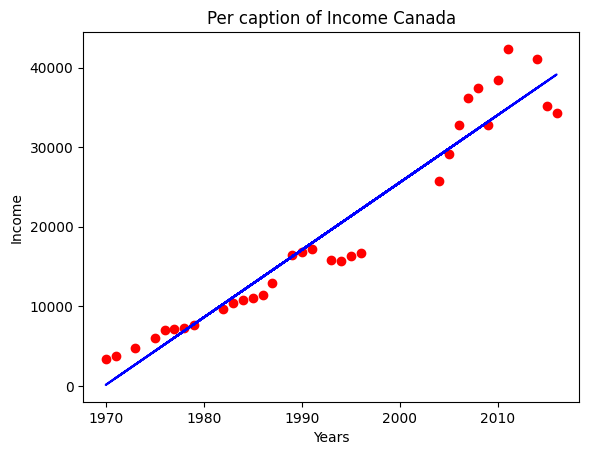

In [24]:
# Scatter plot (actual data)
plt.scatter(x_train, y_train, color='red')

# Regression line (predicted)
plt.plot(x_train, model.predict(x_train), color='blue')

plt.title("Per caption of Income Canada")
plt.xlabel("Years")
plt.ylabel("Income")

plt.show()